# ROS effects

In [1]:
using ModelingToolkit
using OrdinaryDiffEq, DiffEqCallbacks
using Plots
using CSV
using DataFrames
using Dates
using CaMKIIModel
using CaMKIIModel: second, μM
Plots.default(lw=1.5)

## Setup model

In [2]:
sys = build_neonatal_ecc_sys(simplify=true, reduce_iso=true, reduce_camk=true)
tend = 205second
prob = ODEProblem(sys, [], tend)
stimstart = 30second
stimend = 120second
@unpack Istim = sys
callback = build_stim_callbacks(Istim, stimend; period=1second, starttime=stimstart)
alg = KenCarp47()

KenCarp47(; linsolve = nothing, nlsolve = OrdinaryDiffEqNonlinearSolve.NLNewton{Rational{Int64}, Rational{Int64}, Rational{Int64}, Rational{Int64}}(1//100, 10, 1//5, 1//5, false, true, 0//1), precs = DEFAULT_PRECS, smooth_est = true, extrapolant = linear, controller = PI, autodiff = ADTypes.AutoForwardDiff(),)

## Comparisons

In [3]:
@time sol = solve(prob, alg; callback)

  7.285494 seconds (26.83 M allocations: 1.207 GiB, 3.76% gc time, 84.86% compilation time)


retcode: Success
Interpolation: 3rd order Hermite
t: 4071-element Vector{Float64}:
      0.0
      0.019333123284849308
      0.09098129546757994
      0.20735582943983855
      0.45611910276862533
      1.0472562928406122
      2.0342667657223696
      3.451776641148454
      6.733792423912806
     12.450117081023194
      ⋮
 153525.25012366346
 158165.8598019807
 163776.6411118618
 169611.6642461836
 176342.19489586214
 183684.1140466068
 191258.90946281631
 199427.37350661293
 205000.0
u: 4071-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.0025985659590295374, 829.9994975880693, 829.9999654017583, 0.007020208561323646, 0.9660018276402699, 0.2215639938807744, 0.09242766669618695, 0.001879826176081169, 0.009769882842069916, 0.2608055799112056  …  0.12113000000000405, 0.12113000000038378, 0.1211300000138

ROS 0.1uM

In [4]:
prob2 = remake(prob, p=[sys.ROS => 0.1μM])
@time sol2 = solve(prob2, alg; callback)

  1.095178 seconds (40.80 k allocations: 8.495 MiB, 6.53% gc time)


retcode: Success
Interpolation: 3rd order Hermite
t: 4072-element Vector{Float64}:
      0.0
      0.019333123284849367
      0.09098129546758021
      0.20735582943983916
      0.45611910276862666
      1.0472562928406153
      2.0342667657223754
      3.451776641148464
      6.733792423912826
     12.45011708102323
      ⋮
 152613.47237072335
 157039.85798296845
 162443.11402596254
 168307.23424107043
 175796.88765066428
 183286.54106025814
 192001.0511843476
 201547.44872183338
 205000.0
u: 4072-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.0025985659590295374, 829.9994975880693, 829.9999654017583, 0.007020208561323646, 0.9660018276402699, 0.2215639938807744, 0.09242766669618695, 0.001879826176081169, 0.009769882842069916, 0.2608055799112056  …  0.12113000000000405, 0.12113000000038378, 0.12113000001

ROS 0.5uM

In [5]:
prob3 = remake(prob, p=[sys.ROS => 0.5μM])
@time sol3 = solve(prob3, alg; callback)

  1.034631 seconds (38.87 k allocations: 8.462 MiB)


retcode: Success
Interpolation: 3rd order Hermite
t: 4070-element Vector{Float64}:
      0.0
      0.01933312328485172
      0.09098129546759129
      0.20735582943986441
      0.4561191027686822
      1.047256292840743
      2.0342667657226237
      3.451776641148885
      6.7337924239136475
     12.45011708102475
      ⋮
 148407.71053766683
 152963.08286658817
 157518.4551955095
 163268.15494025752
 169694.74223955238
 177941.12600875087
 186187.50977794937
 195845.6756684691
 205000.0
u: 4070-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.002598565959029538, 829.9994975880693, 829.9999654017583, 0.007020208561323646, 0.9660018276402699, 0.2215639938807744, 0.09242766669618695, 0.001879826176081169, 0.009769882842069916, 0.2608055799112056  …  0.12113000000000405, 0.12113000000038378, 0.121130000013893

## Comparisons

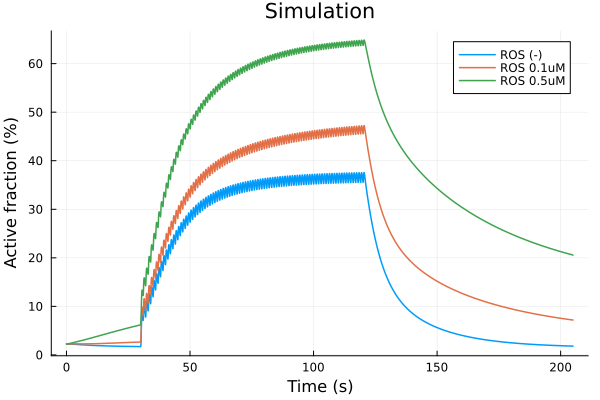

In [6]:
i = (sys.t / 1000, sys.CaMKAct * 100)
plot(sol, idxs=i, lab="ROS (-)")
plot!(sol2, idxs=i, lab="ROS 0.1uM")
plot!(sol3, idxs=i, lab="ROS 0.5uM")
plot!(xlabel="Time (s)", ylabel="Active fraction (%)", title="Simulation")

In [7]:
savefig("ros-camkii.pdf")
savefig("ros-camkii.png")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/ros-camkii.png"

Oxidized fraction

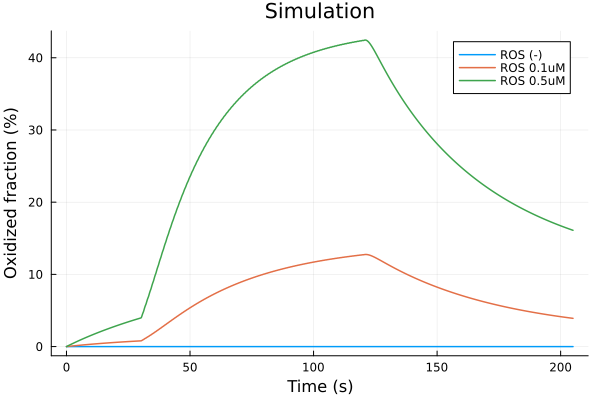

In [8]:
i = (sys.t / 1000, 100 * (sys.CaMKBOX + sys.CaMKPOX + sys.CaMKAOX + sys.CaMKOX ))
plot(sol, idxs=i, lab="ROS (-)")
plot!(sol2, idxs=i, lab="ROS 0.1uM")
plot!(sol3, idxs=i, lab="ROS 0.5uM")
plot!(xlabel="Time (s)", ylabel="Oxidized fraction (%)", title="Simulation")

In [9]:
savefig("ros-camkiiox.pdf")
savefig("ros-camkiiox.png")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/ros-camkiiox.png"

## Experimental data

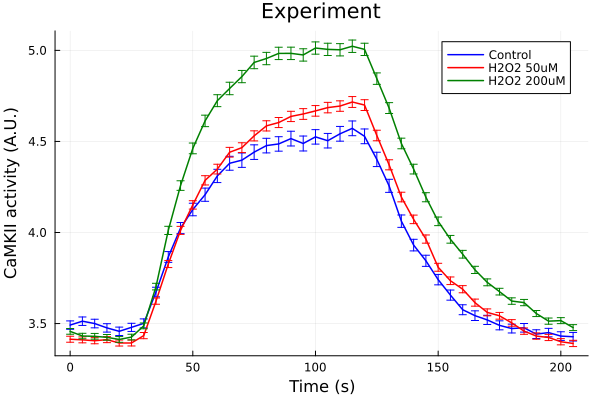

In [10]:
chemicaldf = CSV.read(joinpath(@__DIR__, "data/CaMKAR-chemical.csv"), DataFrame)
ts = Dates.value.(chemicaldf[!, "Time"]) ./ 10^9
ctl = chemicaldf[!, "Ctrl Mean"]
ctl_error = chemicaldf[!, "Ctrl SD"] ./ sqrt.(chemicaldf[!, "Ctrl N"])

ros50 = chemicaldf[!, "H2O2 50uM Mean"]
ros50_error = chemicaldf[!, "H2O2 50uM SD"] ./ sqrt.(chemicaldf[!, "H2O2 50uM N"])
ros200 = chemicaldf[!, "H2O2 200uM Mean"]
ros200_error = chemicaldf[!, "H2O2 200uM SD"] ./ sqrt.(chemicaldf[!, "H2O2 200uM N"])

plot(ts, ctl, yerr=ctl_error, lab="Control", color=:blue, markerstrokecolor=:blue)
plot!(ts, ros50, yerr=ros50_error, lab="H2O2 50uM", color=:red, markerstrokecolor=:red)
plot!(ts, ros200, yerr=ros200_error, lab="H2O2 200uM", color=:green, markerstrokecolor=:green)
plot!(xlabel="Time (s)", ylabel="CaMKII activity (A.U.)", title="Experiment")

In [11]:
savefig("ros-exp.pdf")
savefig("ros-exp.png")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/ros-exp.png"

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*